# Syriac Calamari Validation CER

Evaluate a Calamari checkpoint on the Syriac validation split and report character error rate (CER).

Default paths:
- Checkpoint: `outputs/calamari-syriac-scratch/best.ckpt`
- Validation set: `data/calamari_pack_syriac/SMMJ_00036/val`


In [6]:
from pathlib import Path
import subprocess
import tempfile
from statistics import mean, median
from IPython.display import display, Image as IPyImage


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() or ((candidate / "outputs").exists() and (candidate / "data").exists()):
            return candidate
    raise RuntimeError("Could not locate repo root from current notebook working directory.")


REPO = find_repo_root(Path.cwd())
CHECKPOINT = REPO / "outputs" / "calamari-syriac-scratch" / "best.ckpt"
EVAL_DIR = REPO / "data" / "calamari_pack_syriac" / "SMMJ_00036" / "val"
PREDICT_BIN = REPO / ".venv" / "bin" / "calamari-predict"

# Set to True only if your Calamari/TensorFlow environment can really use CUDA.
USE_GPU = False
GPU_ID = "0"

IMAGE_GLOBS = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff")
val_images = sorted({p for pattern in IMAGE_GLOBS for p in EVAL_DIR.glob(pattern)})

assert PREDICT_BIN.exists(), f"Missing calamari-predict binary: {PREDICT_BIN}"
assert CHECKPOINT.exists(), f"Missing checkpoint: {CHECKPOINT}"
assert EVAL_DIR.exists(), f"Missing evaluation directory: {EVAL_DIR}"
assert val_images, f"No validation images found in {EVAL_DIR}"

print(f"Repo root:           {REPO}")
print(f"Checkpoint:          {CHECKPOINT}")
print(f"Validation dir:      {EVAL_DIR}")
print(f"calamari-predict:    {PREDICT_BIN}")
print(f"Validation samples:  {len(val_images)}")
print(f"Prediction device:   {'GPU ' + GPU_ID if USE_GPU else 'CPU'}")


Repo root:           /home/math/gupta/work/greek_byzantine/greek-foundation
Checkpoint:          /home/math/gupta/work/greek_byzantine/greek-foundation/outputs/calamari-syriac-scratch/best.ckpt
Validation dir:      /home/math/gupta/work/greek_byzantine/greek-foundation/data/calamari_pack_syriac/SMMJ_00036/val
calamari-predict:    /home/math/gupta/work/greek_byzantine/greek-foundation/.venv/bin/calamari-predict
Validation samples:  277
Prediction device:   CPU


In [7]:
def predict_with_checkpoint(checkpoint: Path, image_paths: list[Path]) -> dict[str, str]:
    with tempfile.TemporaryDirectory() as tmp_dir:
        cmd = [
            str(PREDICT_BIN),
            "--checkpoint", str(checkpoint),
            "--data.images", *[str(p) for p in image_paths],
            "--data.pred_extension", ".pred.txt",
            "--output_dir", tmp_dir,
        ]
        if USE_GPU:
            cmd.extend(["--predictor.device.gpus", GPU_ID])

        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print(proc.stdout[-2000:])
            print(proc.stderr[-2000:])
            raise RuntimeError(f"calamari-predict failed for {checkpoint}")

        predictions = {}
        for pred_file in Path(tmp_dir).glob("*.pred.txt"):
            predictions[pred_file.stem.replace(".pred", "")] = pred_file.read_text("utf-8").strip()
        return predictions


def levenshtein_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    prev = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        curr = [i]
        for j, char_b in enumerate(b, start=1):
            cost = 0 if char_a == char_b else 1
            curr.append(min(
                prev[j] + 1,
                curr[j - 1] + 1,
                prev[j - 1] + cost,
            ))
        prev = curr
    return prev[-1]


def character_error_rate(ground_truth: str, prediction: str) -> float:
    if not ground_truth:
        return 0.0 if not prediction else 1.0
    return levenshtein_distance(ground_truth, prediction) / len(ground_truth)


Loaded 277 predictions.
Evaluating 30 random validation samples.

----------------------------------------------------------------------------------------------------
Sample 01 | 0231_SMMJ_00036__236__003


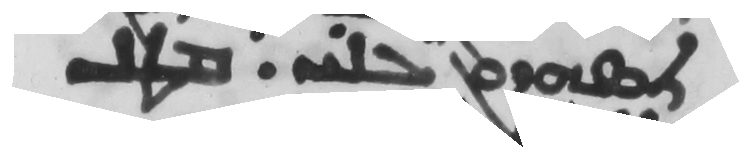

GT:   ܬܣܗܕܘܢ ܥܠܝ. ܡܛܠ
PRED: ܬܣܗܪܘܢ ܥܠܝ. ܡܛܠ
CER:  0.0667 (6.67%)
----------------------------------------------------------------------------------------------------
Sample 02 | 0231_SMMJ_00036__236__012


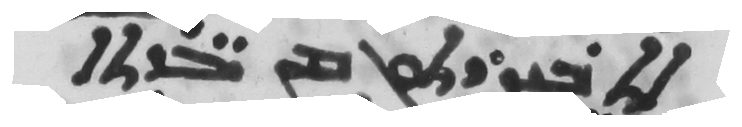

GT:   ܐܬܒܨܪܬܘܢ ܡܢ ܥ̈ܕܬܐ
PRED: ܐܬܒܨܪܬܘܢ ܡܢ ܥܕܬܐ
CER:  0.0588 (5.88%)
----------------------------------------------------------------------------------------------------
Sample 03 | 0231_SMMJ_00036__236__013


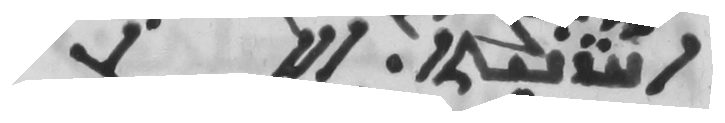

GT:   ܐܚܪ̈ܢܝܬܐ. ܐܠܐ ܐܢ
PRED: ܐܚܪ̈ܢܝܬܐ.ܐܠܐ ܐܢ
CER:  0.0625 (6.25%)
----------------------------------------------------------------------------------------------------
Sample 04 | 0231_SMMJ_00036__236__015


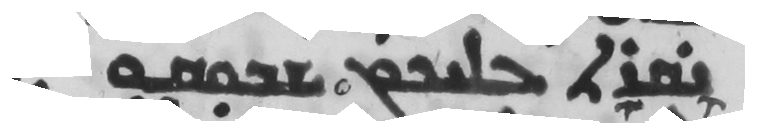

GT:   ܝܩܪܬ ܥܠܝܟܘܢ. ܫܒܘܩܘ܀
PRED: ܢܩܪܬ ܥܠܝܟܘܢ ܫܒܘܩܘ
CER:  0.1579 (15.79%)
----------------------------------------------------------------------------------------------------
Sample 05 | 0231_SMMJ_00036__236__016


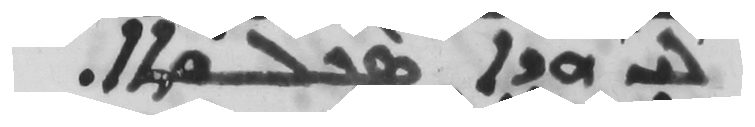

GT:   ܠܝ ܗܕܐ ܣܟܠܘܬܐ.
PRED: ܠܝ ܗܕܐ ܣܟܠܘܬܐ.
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 06 | 0231_SMMJ_00036__236__039


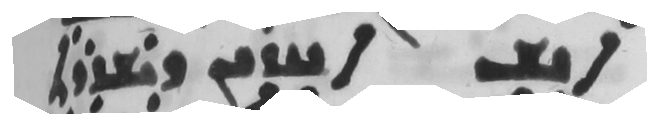

GT:   ܐܢܫ ܐܚܪܝܢ ܕܫܕܪܐ
PRED: ܐܢܫ ܐܚܕܝܢ ܕܝܫܪܐ
CER:  0.2000 (20.00%)
----------------------------------------------------------------------------------------------------
Sample 07 | 0231_SMMJ_00036__236__040


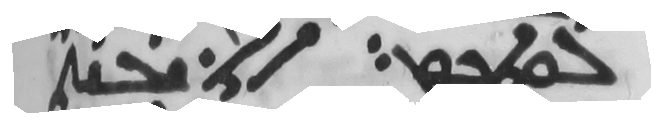

GT:   ܠܘܬܟܘܢ: ܐܬܝܥܢܬ
PRED: ܠܘܬܟܘܢ ܐܬܝܥܢܐ
CER:  0.1429 (14.29%)
----------------------------------------------------------------------------------------------------
Sample 08 | 0231_SMMJ_00036__236__044


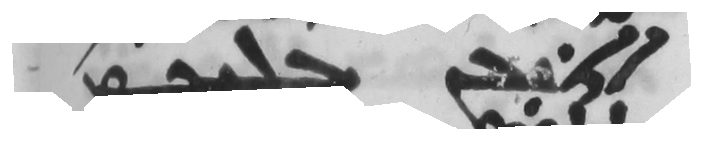

GT:   ܐܬܝܥܢ ܥܠܝܟܘܢ
PRED: ܐܬܝܥܢ ܥܠܝܟܘܢ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 09 | 0231_SMMJ_00036__236__047


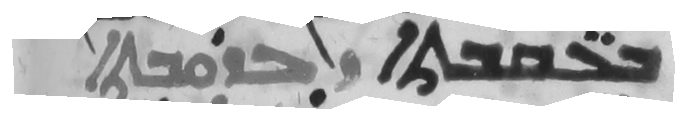

GT:   ܒܥ̈ܩܒܬܐ ܕܥܪܘܒܬܐ
PRED: ܒܥܩܒܬܐ ܕܥܪܘܒܬܐ
CER:  0.0667 (6.67%)
----------------------------------------------------------------------------------------------------
Sample 10 | 0231_SMMJ_00036__236__052


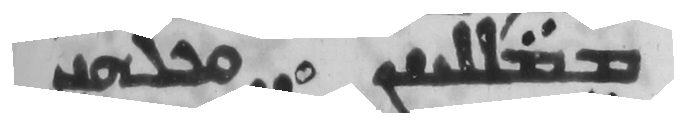

GT:   ܡܡܠܠܝܢܢ ܘܟܠܗܝܢ
PRED: ܡܡܠܠܝܢܢ ܘܟܠܗܝܢ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 11 | 0231_SMMJ_00036__236__057


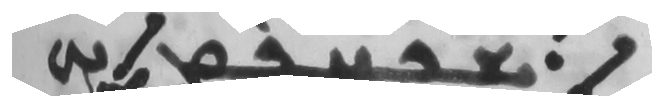

GT:   ܐܫܟܚܟܘܢ ܐܝܟ
PRED: ܐܝܫܟܝܟܘܢ ܐܢܟ
CER:  0.2727 (27.27%)
----------------------------------------------------------------------------------------------------
Sample 12 | 0231_SMMJ_00036__236__071


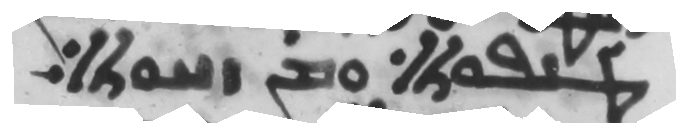

GT:   ܛܢܦܘܬܐ ܘܡܢ ܙܚܘܬܐ:
PRED: ܛܢܦܘܬܐ ܘܡܢ ܕܚܘܬܐ.
CER:  0.1176 (11.76%)
----------------------------------------------------------------------------------------------------
Sample 13 | 0231_SMMJ_00036__236__087


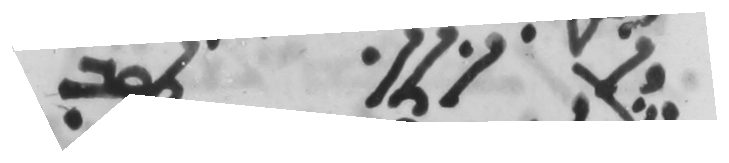

GT:   ܕܐܢ ܐܬܐ ܬܘܒ
PRED: ܕܐܢ ܐܬܐ ܬܘܒ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 14 | 0231_SMMJ_00036__236__101


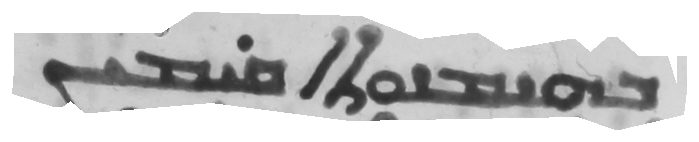

GT:   ܒܗܝܡܢܘܬܐ ܩܝܡܝܢ
PRED: ܒܗܝܡܢܘܬܐ ܩܝܡܝܢ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 15 | 0231_SMMJ_00036__236__108


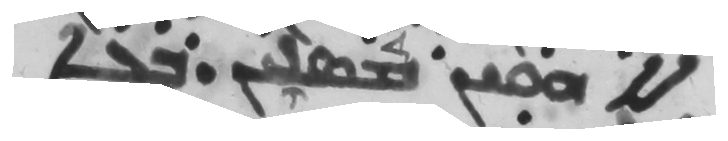

GT:   ܠܐ ܗܘܝܢ ܡܣܠܝܢ. ܒܥܐ
PRED: ܠܐ ܗܘܝܢ ܡܣܠܝܢ. ܒܥܐ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 16 | 0231_SMMJ_00036__236__111


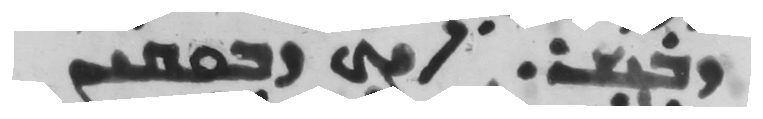

GT:   ܕܒܢܫ܇ ܐܝܟ ܕܒܘܩܝܢ
PRED: ܕܒܝܫ. ܐܝܟ ܕܒܘܩܝܢ
CER:  0.1250 (12.50%)
----------------------------------------------------------------------------------------------------
Sample 17 | 0231_SMMJ_00036__236__112


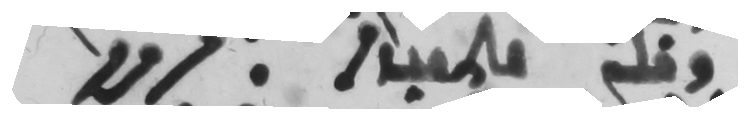

GT:   ܕܝܠܢ ܢܬܚܙܐ: ܐܠܐ
PRED: ܕܝܢ ܢܬܚܪܐ. ܐܠܐ
CER:  0.2000 (20.00%)
----------------------------------------------------------------------------------------------------
Sample 18 | 0231_SMMJ_00036__236__114


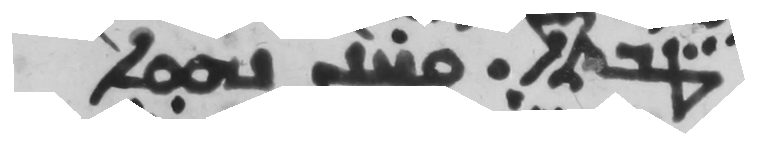

GT:   ܛܒܬܐ. ܘܚܢܢ ܢܗܘܐ
PRED: ܛܒܬܐ. ܘܚܢ ܢܗܘܐ
CER:  0.0667 (6.67%)
----------------------------------------------------------------------------------------------------
Sample 19 | 0231_SMMJ_00036__236__119


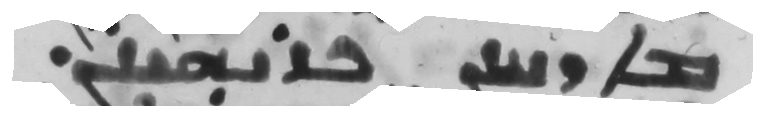

GT:   ܡܐ ܕܚܢܢ ܟܪܝܗܝܢܢ.
PRED: ܡܐ ܕܚܢ ܟܪܝܗܝܢܢ.
CER:  0.0625 (6.25%)
----------------------------------------------------------------------------------------------------
Sample 20 | 0231_SMMJ_00036__236__125


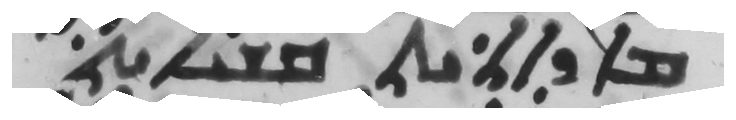

GT:   ܡܐ ܕܐܬܝܬ ܩܫܝܐܝܬ
PRED: ܡܐ ܕܐܬܝܬ ܡܫܝܐܝܬ
CER:  0.0667 (6.67%)
----------------------------------------------------------------------------------------------------
Sample 21 | 0232_SMMJ_00036__237__003


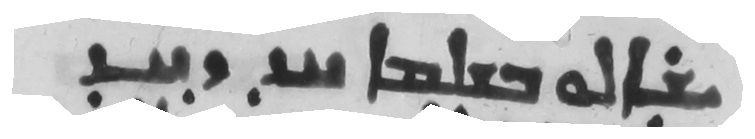

GT:   ܫܐܠܘ ܒܫܠܡܐ ܚܕ ܕܚܕ
PRED: ܫܐܠܘ ܒܫܠܡܐ ܚܕ ܕܚܕ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 22 | 0232_SMMJ_00036__237__005


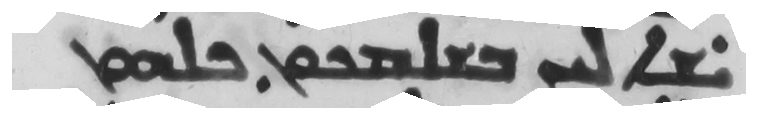

GT:   ܫܐܠܝܢ ܒܫܠܡܟܘܢ ܟܠܗܘܢ
PRED: ܫܐܠܝܢ ܒܫܠܡܟܘܢ ܟܠܗܘܢ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 23 | 0232_SMMJ_00036__237__041


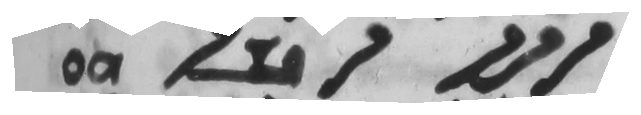

GT:   ܐܠܐ ܐܢܫܐ ܗܘ
PRED: ܐܠܐ ܐܢܫܐ ܗܘ
CER:  0.0000 (0.00%)
----------------------------------------------------------------------------------------------------
Sample 24 | 0232_SMMJ_00036__237__057


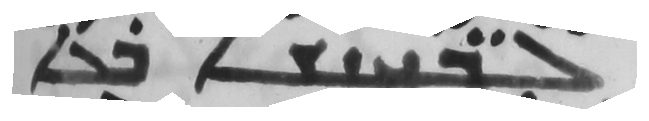

GT:   ܠܒ̈ܢܝܢܫܐ ܒ̇ܥܐ
PRED: ܠܒܚܢܫܐ ܒܥܐ
CER:  0.3077 (30.77%)
----------------------------------------------------------------------------------------------------
Sample 25 | 0232_SMMJ_00036__237__069


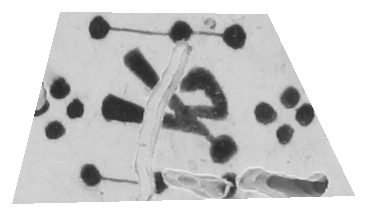

GT:   ܀܏ܟܓ܀
PRED: ܀ܘ܀
CER:  0.6000 (60.00%)
----------------------------------------------------------------------------------------------------
Sample 26 | 0232_SMMJ_00036__237__077


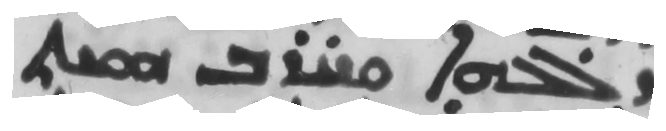

GT:   ܕܐܠܗܐ ܘܚ̇ܪܒ ܗܘܝܬ
PRED: ܕܐܠܗܐ ܘܚܪܒ ܗܝܬ
CER:  0.1250 (12.50%)
----------------------------------------------------------------------------------------------------
Sample 27 | 0232_SMMJ_00036__237__079


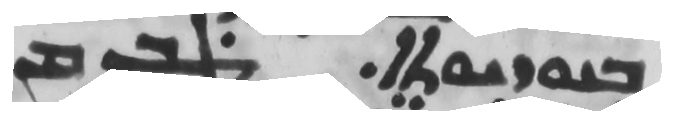

GT:   ܒܝܘܕܝܘܬܐ. ܛܒܢ ܡܢ
PRED: ܒܝܘܕܝܘܬܐ. ܛܒ ܡܢ
CER:  0.0625 (6.25%)
----------------------------------------------------------------------------------------------------
Sample 28 | 0232_SMMJ_00036__237__092


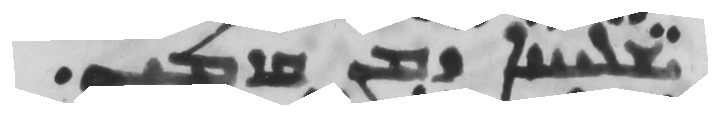

GT:   ܫ̈ܠܝܚܐ ܕܡ̣ܢ ܩܕܡܝ.
PRED: ܫܠܝܚܢܐ ܕܡܢ ܩܕܡܝܢ.
CER:  0.2353 (23.53%)
----------------------------------------------------------------------------------------------------
Sample 29 | 0232_SMMJ_00036__237__121


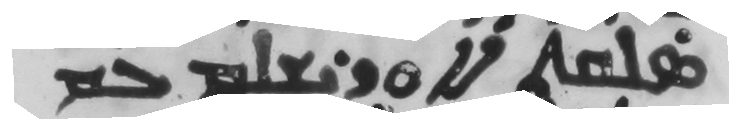

GT:   ܣܠܩܬ ܠܐܘܪܝܫܠܡ ܥܡ
PRED: ܣܠܩܬ ܠܐܘܪܫܠܡ ܥܡ
CER:  0.0625 (6.25%)
----------------------------------------------------------------------------------------------------
Sample 30 | 0232_SMMJ_00036__237__134


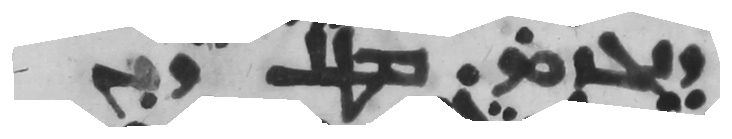

GT:   ܕܢܓܙܘܪ: ܡܛܠ ܕܝܢ
PRED: ܕܓܕܘܕ ܡܛܠ ܕܝܢ
CER:  0.2667 (26.67%)

Average CER over 30 random validation samples: 0.1109 (11.09%)
Median CER over 30 random validation samples:  0.0667 (6.67%)


In [8]:
import random

predictions = predict_with_checkpoint(CHECKPOINT, val_images)
print(f"Loaded {len(predictions)} predictions.")

sample_size = min(30, len(val_images))
rng = random.Random(42)
sampled_images = sorted(rng.sample(val_images, k=sample_size), key=lambda p: p.stem)
print(f"Evaluating {sample_size} random validation samples.\n")

rows = []
for idx, img_path in enumerate(sampled_images, start=1):
    gt_path = EVAL_DIR / f"{img_path.stem}.gt.txt"
    ground_truth = gt_path.read_text("utf-8").strip()
    prediction = predictions.get(img_path.stem, "")
    cer = character_error_rate(ground_truth, prediction)
    rows.append({
        "stem": img_path.stem,
        "image_path": img_path,
        "ground_truth": ground_truth,
        "prediction": prediction,
        "cer": cer,
    })

    print("-" * 100)
    print(f"Sample {idx:02d} | {img_path.stem}")
    display(IPyImage(filename=str(img_path)))
    print(f"GT:   {ground_truth}")
    print(f"PRED: {prediction}")
    print(f"CER:  {cer:.4f} ({cer * 100:.2f}%)")

avg_cer = mean(row["cer"] for row in rows)
median_cer = median(row["cer"] for row in rows)
print("\n" + "=" * 100)
print(f"Average CER over {sample_size} random validation samples: {avg_cer:.4f} ({avg_cer * 100:.2f}%)")
print(f"Median CER over {sample_size} random validation samples:  {median_cer:.4f} ({median_cer * 100:.2f}%)")



Worst examples


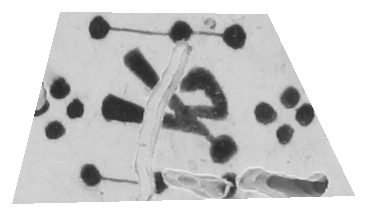

0232_SMMJ_00036__237__069 | CER=60.00%
GT:   ܀܏ܟܓ܀
PRED: ܀ܘ܀



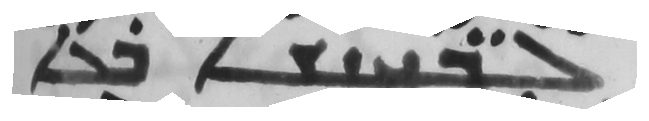

0232_SMMJ_00036__237__057 | CER=30.77%
GT:   ܠܒ̈ܢܝܢܫܐ ܒ̇ܥܐ
PRED: ܠܒܚܢܫܐ ܒܥܐ



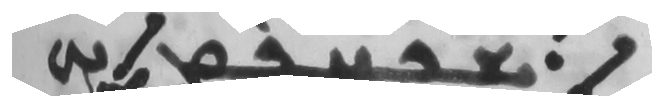

0231_SMMJ_00036__236__057 | CER=27.27%
GT:   ܐܫܟܚܟܘܢ ܐܝܟ
PRED: ܐܝܫܟܝܟܘܢ ܐܢܟ


Best examples


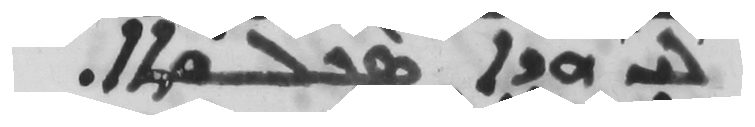

0231_SMMJ_00036__236__016 | CER=0.00%
GT:   ܠܝ ܗܕܐ ܣܟܠܘܬܐ.
PRED: ܠܝ ܗܕܐ ܣܟܠܘܬܐ.



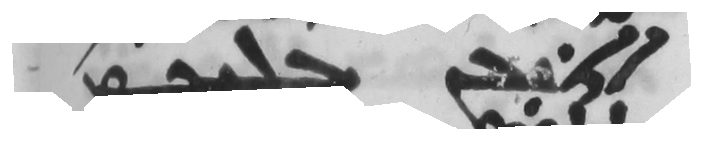

0231_SMMJ_00036__236__044 | CER=0.00%
GT:   ܐܬܝܥܢ ܥܠܝܟܘܢ
PRED: ܐܬܝܥܢ ܥܠܝܟܘܢ



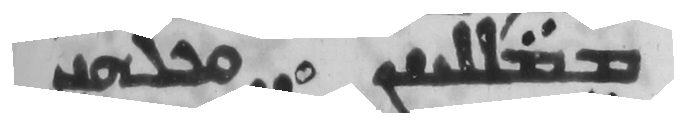

0231_SMMJ_00036__236__052 | CER=0.00%
GT:   ܡܡܠܠܝܢܢ ܘܟܠܗܝܢ
PRED: ܡܡܠܠܝܢܢ ܘܟܠܗܝܢ



In [9]:
# Show a few best and worst examples visually.
worst_rows = sorted(rows, key=lambda item: item["cer"], reverse=True)[:3]
best_rows = sorted(rows, key=lambda item: item["cer"])[:3]

for label, subset in (("Worst", worst_rows), ("Best", best_rows)):
    print(f"\n{label} examples")
    for row in subset:
        display(IPyImage(filename=str(row["image_path"])))
        print(f"{row['stem']} | CER={row['cer'] * 100:.2f}%")
        print(f"GT:   {row['ground_truth']}")
        print(f"PRED: {row['prediction']}")
        print()
